In [2]:
40

40

In [19]:
# only linux support
# !pip install vllm

In [6]:
# !pip install git+https://github.com/chatdoc-com/OCRFlux.git

In [8]:
# !pip install Pillow transformers accelerate

In [10]:
# !huggingface-cli download ChatDOC/OCRFlux-3B --local-dir ./models/OCRFlux-3B

In [11]:
import os, base64, textwrap
from pathlib import Path
from IPython.display import display, Markdown, Image as IPImage

# ── Edit these paths ──────────────────────────────────
MODEL_DIR  = './models/OCRFlux-3B'   # local model weights
IMAGE_PATH = 'cropped-img.png'            # your input image
OUTPUT_DIR = './ocr_outputs'
GPU_UTIL   = 0.8                     # VRAM fraction (0.0–1.0)
MAX_TOKENS = 4096
# ──────────────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('✅ Config ready')
print(f'   Model  : {MODEL_DIR}')
print(f'   Image  : {IMAGE_PATH}')
print(f'   Output : {OUTPUT_DIR}')

✅ Config ready
   Model  : ./models/OCRFlux-3B
   Image  : cropped-img.png
   Output : ./ocr_outputs


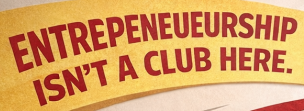

cropped-img.png  |  69.7 KB


In [12]:
if Path(IMAGE_PATH).exists():
    display(IPImage(filename=IMAGE_PATH, width=600))
    kb = Path(IMAGE_PATH).stat().st_size / 1024
    print(f'{IMAGE_PATH}  |  {kb:.1f} KB')
else:
    print(f'⚠️  Not found: {IMAGE_PATH}')
    print('   Update IMAGE_PATH in Step 3 and re-run.')

In [17]:
from vllm import LLM, SamplingParams

ModuleNotFoundError: No module named 'vllm'

In [ ]:

print('Loading OCRFlux-3B …')
llm = LLM(
    model=MODEL_DIR,
    dtype='half',                  # float16 — required for T4/V100 (compute < 8.0)
    gpu_memory_utilization=GPU_UTIL,
    max_model_len=8192,
    trust_remote_code=True,
)
print('✅ Model ready!')

In [31]:
from ocrflux.inference import parse
IMAGE_PATH = "/content/img9.png"
result = parse(llm, IMAGE_PATH, max_page_retries=2)

if result:
    markdown_text = result['document_text']
    print(f'✅ Extracted {len(markdown_text):,} characters')
else:
    markdown_text = ''
    print('❌ parse() returned None — check image path and model directory')

Processed prompts: 100%|██████████| 1/1 [00:02<00:00,  2.15s/it, est. speed input: 383.81 toks/s, output: 21.40 toks/s]
Processed prompts: 0it [00:00, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

✅ Extracted 21 characters


In [32]:
markdown_text

'UNLOCK YOUR POTENTIAL'